# Telco Customer Churn: AutoML Baseline dengan PyCaret

Notebook ini mendemonstrasikan fase eksperimen awal (baseline) menggunakan pustaka **PyCaret AutoML**. Tujuannya adalah untuk secara cepat mengevaluasi performa prediktif berbagai algoritma klasifikasi *out-of-the-box* pada data mentah sebelum kita beralih ke rekayasa fitur kustom (Feature Engineering) dan optimasi lanjutan (Optuna).

**Tujuan Fase Ini:**
1. Mendapatkan patokan performa (*baseline benchmark*) untuk AUC dan F1-Score.
2. Mengidentifikasi keluarga algoritma (*tree-based, linear, etc.*) yang paling cocok dengan data.
3. Menjadi dasar rasionalisasi sebelum membangun *custom pipeline* Scikit-Learn.

In [11]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Import spesifik dari PyCaret
from pycaret.classification import *

## 1. Persiapan Data Mentah (*Data Ingestion*)

In [12]:
# Load dataset
data_candidates = ['data/WA_Fn-UseC_-Telco-Customer-Churn.csv', '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv', 'WA_Fn-UseC_-Telco-Customer-Churn.csv']
data_path = next((p for p in data_candidates if os.path.exists(p)), 'data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = pd.read_csv(data_path)

# Drop ID karena merupakan variabel arbitrer yang tidak prediktif
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

# TotalCharges merupakan string yang mengandung spasi ' ' untuk pelanggan baru. 
# Kita ubah menjadi numerik.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

display(df.head())
display(df.info())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


None

## 2. Inisialisasi Environment PyCaret (`setup`)

Pada tahap ini, kita mendefinisikan tipe variabel secara manual untuk mencegah kesalahan deteksi. Kita menggunakan *Median Imputer* untuk menangani *missing values* di `TotalCharges`. Data dipartisi dengan target 'Churn' dan stratifikasi.

In [13]:
# Menentukan kolom berdasarkan tipenya
categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
                        'PaperlessBilling', 'PaymentMethod']

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Inisialisasi setup PyCaret
clf_setup = setup(
    data=df,
    target='Churn',
    session_id=42, # Untuk reproduksibilitas
    imputation_type='simple',
    numeric_imputation='median',
    categorical_features=categorical_features,
    numeric_features=numeric_features,
    fold=10,       # 10-Fold Cross Validation
    verbose=True   # Menampilkan grid setup
)

,Description,Value
0,Session id,42
1,Target,Churn
2,Target type,Binary
3,Target mapping,"No: 0, Yes: 1"
4,Original data shape,"(7043, 20)"
5,Transformed data shape,"(7043, 41)"
6,Transformed train set shape,"(4930, 41)"
7,Transformed test set shape,"(2113, 41)"
8,Numeric features,3
9,Categorical features,15


## 3. Evaluasi *AutoML* (`compare_models`)

Fungsi ini melatih dan mengevaluasi lebih dari 14 algoritma klasifikasi secara simultan menggunakan *10-Fold Stratified Cross Validation*. Kita akan mengurutkan hasilnya berdasarkan **AUC**.

In [14]:
# Membandingkan seluruh model klasifikasi
best_model = compare_models(sort='AUC', n_select=1)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8020,0.8471,0.8020,0.7926,0.7942,0.4568,0.4624,0.1860
ada,Ada Boost Classifier,0.8010,0.8462,0.8010,0.7926,0.7940,0.4575,0.4626,0.1250
catboost,CatBoost Classifier,0.8022,0.8457,0.8022,0.7926,0.7935,0.4537,0.4608,1.3720
lr,Logistic Regression,0.8028,0.8452,0.8028,0.7952,0.7970,0.4674,0.4711,1.4940
lightgbm,Light Gradient Boosting Machine,0.7947,0.8399,0.7947,0.7857,0.7878,0.4418,0.4460,0.1960
ridge,Ridge Classifier,0.8008,0.8374,0.8008,0.7911,0.7924,0.4511,0.4576,0.0790
lda,Linear Discriminant Analysis,0.7994,0.8374,0.7994,0.7928,0.7946,0.4630,0.4657,0.0770
rf,Random Forest Classifier,0.7915,0.8264,0.7915,0.7798,0.7815,0.4208,0.4279,0.1840
xgboost,Extreme Gradient Boosting,0.7846,0.8264,0.7846,0.7752,0.7778,0.4163,0.4198,0.1120
nb,Naive Bayes,0.6913,0.8231,0.6913,0.7984,0.7090,0.3799,0.4281,0.0770


## 4. Analisis Model Terbaik

Setelah benchmark selesai, mari kita lihat performa dari model terbaik (berdasarkan klasemen metrik di atas). PyCaret menyediakan visualisasi praktis untuk melihat ROC Curve dan Confusion Matrix.

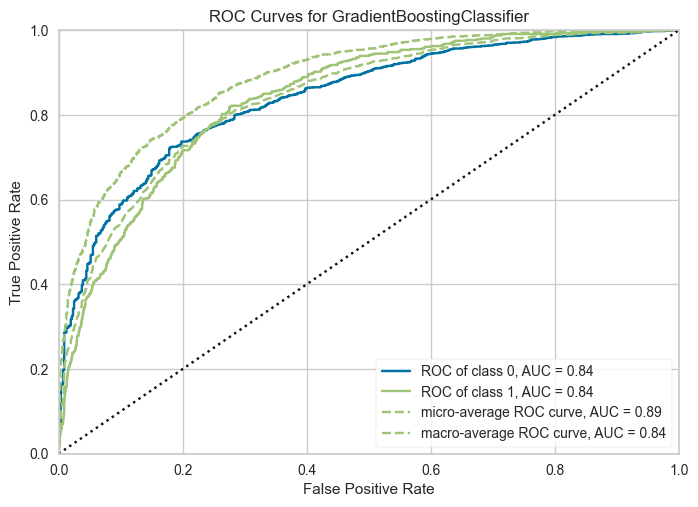

In [15]:
# Plot ROC-AUC Curve
plot_model(best_model, plot='auc')

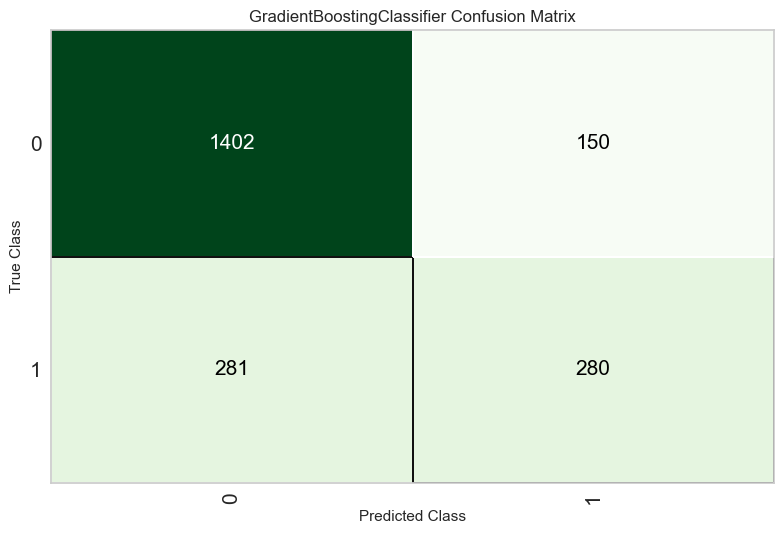

In [16]:
# Plot Confusion Matrix
plot_model(best_model, plot='confusion_matrix')

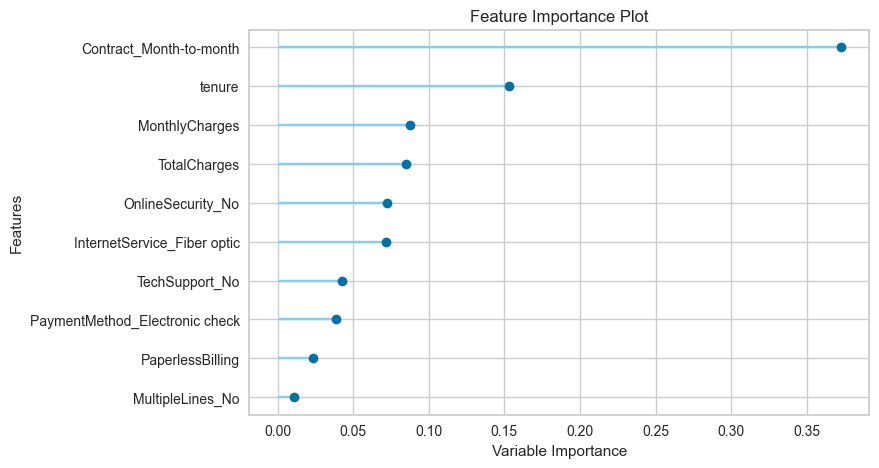

In [17]:
# Plot Feature Importance (khusus model berbasis pohon)
try:
    plot_model(best_model, plot='feature')
except:
    print("Feature importance tidak didukung untuk tipe model ini.")

## 5. Hyperparameter Tuning di PyCaret (`tune_model`)

Mari kita uji proses otomatisasi optimasi dari PyCaret menggunakan fungsi `tune_model()`. Fungsi ini secara *default* akan menggunakan `RandomizedSearchCV` untuk mencari parameter terbaik guna memaksimalkan AUC.

In [18]:
# Melakukan hyperparameter tuning pada model terbaik
tuned_best_model = tune_model(best_model, optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8215,0.8547,0.8215,0.8138,0.8153,0.5114,0.5160
1,0.8256,0.8663,0.8256,0.8174,0.8150,0.5043,0.5168
2,0.8316,0.8516,0.8316,0.8254,0.8267,0.5453,0.5490
3,0.8174,0.8730,0.8174,0.8092,0.8026,0.4702,0.4902
4,0.8134,0.8509,0.8134,0.8039,0.8044,0.4814,0.4894
5,0.7972,0.8649,0.7972,0.7889,0.7915,0.4536,0.4563
6,0.7890,0.8288,0.7890,0.7777,0.7804,0.4198,0.4251
7,0.8032,0.8507,0.8032,0.7957,0.7981,0.4713,0.4739
8,0.7748,0.8419,0.7748,0.7665,0.7696,0.3981,0.3998


Fitting 10 folds for each of 10 candidates, totalling 100 fits


## 6. Evaluasi Model Setelah Tuning

Mari kita periksa ROC Curve dari model yang telah melalui proses tuning.

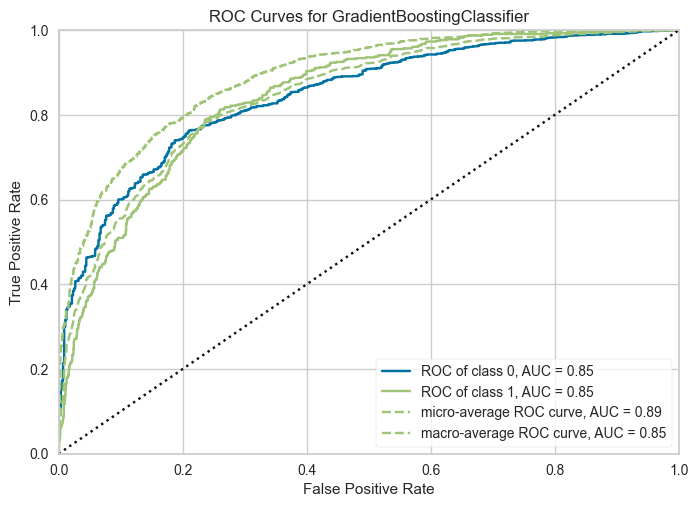

In [19]:
# Plot ROC-AUC Curve model setelah tuning
plot_model(tuned_best_model, plot='auc')

## 7. Kesimpulan Eksperimen Baseline & Tuning PyCaret

Berdasarkan eksperimen di atas, algoritma **Gradient Boosting Classifier (GBC)** dengan fitur mentah mendominasi papan peringkat dan mampu mencapai **AUC** $\approx 0.8509$ setelah proses tuning.

Secara objektif, angka ini **secara marginal lebih tinggi** ($\approx 0.006$) dibandingkan *Custom Pipeline LightGBM* yang dibangun di notebook utama (AUC $\approx 0.8443$). Namun, dalam arsitektur klasifikasi *churn* skala produksi, kita **sengaja memilih untuk tidak menggunakan PyCaret GBC** dan beralih ke *custom pipeline* murni Scikit-Learn dengan **Optuna** karena alasan fundamental berikut:

1. **Multikolinearitas Tersembunyi (Masalah Bisnis)**: GBC di PyCaret membelah data menggunakan fitur mentah (`TotalCharges` dan `MonthlyCharges`) yang sangat berkorelasi. Untuk pelaporan bisnis, kita wajib merekayasa fitur agar bebas multikolinearitas (seperti merangkumnya menjadi `AverageMonthlyCost` di *custom pipeline*) agar operasional tahu persis apa penyebab sesungguhnya dari *churn*.
2. **Keterjelasan Arah (Explainable AI)**: Plot *Feature Importance* bawaan GBC hanya menunjukkan besaran bobot tanpa arah (apakah menaikkan atau menurunkan risiko *churn*). Model LightGBM murni terjamin kompatibilitasnya 100% dengan **SHAP TreeExplainer** yang esensial untuk menjawab pertanyaan "mengapa" secara arah (*log-odds*).
3. **Kustomisasi Fitur Bebas Leakage**: Saat kita membuat turunan fitur secara manual, ia wajib diisolasi ketat di dalam `ColumnTransformer` agar dieksekusi di dalam *cross-validation* terpisah (menghindari 100% *data leakage*). Melakukan ini secara bersih lebih mudah pada *pipeline* murni dibandingkan *wrapper* PyCaret.
4. **Optimasi Berbasis Profit (Unit Economics)**: Di *pipeline* kustom, kita merancang ambang batas (*threshold*) berbasis kalkulasi finansial \$20 biaya vs \$100 profit yang lebih aplikatif bagi tim finansial.

